In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional, Union, Any
import scipy.io as scio
import time

import itertools
import numpy as np
import uuid
import json
import os
import copy
from joblib import Parallel, delayed
import scipy.io as scio

from uqgrid.simulation.dynamics import integrate_system
from uqgrid.simulation.config   import IntegrationConfig
from uqgrid.io.parse            import load_psse, add_dyr

def load_simulation_log(file_path: str = 'simulation_log.json') -> Dict:
    """Load the simulation log containing metadata about all scenarios."""
    with open(file_path, 'r') as f:
        return json.load(f)

def load_state_metadata(file_path: str = 'state_metadata.json') -> Dict:
    """Load the state metadata that describes all state variables."""
    with open(file_path, 'r') as f:
        return json.load(f)

def filter_scenarios(
    simulation_log: Dict, 
    sample_idx: Optional[int] = None,
    fault_location: Optional[int] = None,
    fault_impedance: Optional[float] = None,
    diverged: Optional[bool] = None
) -> Dict:
    """Filter scenarios based on criteria."""
    filtered_log = {}
    
    for scenario_id, data in simulation_log.items():
        match = True

        # if isinstance(data, list):
        #     filtered_log[scenario_id] = []
        #     for i in range(len(data)):
        #         match = True 

        #         if sample_idx is not None and data[i].get('sample_idx') != sample_idx:
        #             match = False
        #         if fault_location is not None and data[i]['fault_location'] != fault_location:
        #             match = False
        #         if fault_impedance is not None and data[i]['fault_impedance'] != fault_impedance:
        #             match = False
        #         if diverged is not None and data[i]['diverged'] != diverged:
        #             match = False
                    
        #         if match:
        #             filtered_log[scenario_id].append(data)

        # else:      
        if sample_idx is not None and data.get('sample_idx') != sample_idx:
            match = False
        if fault_location is not None and data['fault_location'] != fault_location:
            match = False
        if fault_impedance is not None and data['fault_impedance'] != fault_impedance:
            match = False
        if diverged is not None and data['diverged'] != diverged:
            match = False
            
        if match:
            filtered_log[scenario_id] = data
            
    return filtered_log

def find_state_index(
    state_metadata: Dict, 
    model: Optional[str] = None, 
    device_number: Optional[str] = None,
    bus_num: Optional[int] = None,
    state_name: Optional[str] = None
) -> List[int]:
    """Find indices of states matching the criteria."""
    indices = []
    
    for idx, (state_idx, data) in enumerate(state_metadata.items()):
        match = True
        
        if model is not None and data.get('model') != model:
            match = False
        if device_number is not None and str(data.get('device_number')) != str(device_number):
            match = False
        if bus_num is not None and data.get('bus_num') != bus_num:
            match = False
        if state_name is not None and data.get('state_name') != state_name:
            match = False
            
        if match:
            indices.append(int(state_idx))
            
    return indices

def load_scenario_data(scenario_id: str, simulation_log: Dict) -> Dict:
    """Load data for a specific scenario."""
    # if isinstance(simulation_log[scenario_id], list):
    #     results = []
    #     for i in range(len(simulation_log[scenario_id])):
    #         file_path = simulation_log[scenario_id][i]['file']
    #         if not os.path.exists(file_path):
    #             raise FileNotFoundError(f"Scenario data file not found: {file_path}")
            
    #         data = np.load(file_path, mmap_mode='r')
    #         results.append( {
    #             'history': data['history'],
    #             'tvec': data['tvec'],
    #             'metadata': simulation_log[scenario_id],
    #             'p_gen_scaled': data['p_gen_scaled'],
    #             'q_gen_scaled': data['q_gen_scaled'],
    #             'p_load_scaled': data['p_load_scaled'],
    #             'q_load_scaled': data['q_load_scaled'],
    #         })
    #     return results

    # else:

    file_path = simulation_log[scenario_id]['file']
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Scenario data file not found: {file_path}")
    
    data = np.load(file_path, mmap_mode='r')
    return {
        'history': data['history'],
        'tvec': data['tvec'],
        'metadata': simulation_log[scenario_id],
        'p_gen_scaled': data['p_gen_scaled'],
        'q_gen_scaled': data['q_gen_scaled'],
        'p_load_scaled': data['p_load_scaled'],
        'q_load_scaled': data['q_load_scaled'],
    }

def get_state_timeseries(
    scenario_data: Dict, 
    state_idx: int
) -> Tuple[np.ndarray, np.ndarray]:
    """Extract a specific state variable from a scenario."""
    tvec = scenario_data['tvec']
    history = scenario_data['history']
    
    if history is None:
        return np.array([]), np.array([])
    
    state_values = history[state_idx, :].copy()
    return tvec, state_values

def get_state_timeseries_all(
    simulation_log: Dict,
    state_metadata: Dict,
    model: Optional[str] = None,
    device_number: Optional[str] = None,
    bus_num: Optional[int] = None,
    state_name: Optional[str] = None,
    sample_idx: Optional[int] = None,
    fault_location: Optional[int] = None,
    fault_impedance: Optional[float] = None,
    diverged: Optional[bool] = False
) -> Dict[str, Dict[str, Union[np.ndarray, Any]]]:
    """Extract a state variable from multiple scenarios with filtering."""
    # Filter scenarios
    filtered_scenarios = filter_scenarios(
        simulation_log, 
        sample_idx,
        fault_location,
        fault_impedance,
        diverged
    )
    
    # Find state indices
    state_indices = find_state_index(
        state_metadata, 
        model, 
        device_number, 
        bus_num,
        state_name
    )
    
    if not state_indices:
        raise ValueError(f"No states found matching criteria: model={model}, device_number={device_number}, state_name={state_name}")
    
    state_idx = state_indices[0]  # Take the first match if multiple
    
    # Extract data for each scenario
    results = {}
    for scenario_id, scenario_info in filtered_scenarios.items():
        try:
            scenario_data = load_scenario_data(scenario_id, simulation_log)
            # if isinstance(scenario_data, list):
            #     results[scenario_id] = []
            #     for i in range(len(scenario_data)):
            #         tvec, values = get_state_timeseries(scenario_data[i], state_idx)
                    
            #         results[scenario_id].append({
            #             'tvec': tvec,
            #             'values': values,
            #             'metadata': scenario_info
            #         })

            # else:
            tvec, values = get_state_timeseries(scenario_data, state_idx)
            
            results[scenario_id] = {
                'tvec': tvec,
                'values': values,
                'metadata': scenario_info
            }
        except Exception as e:
            print(f"Error loading scenario {scenario_id}: {e}")
    
    return results

def plot_state_comparison(
    results: Dict[str, Dict[str, Union[np.ndarray, Any]]],
    title: str = None,
    xlabel: str = 'Time (s)',
    ylabel: str = None,
    legend_key: str = 'fault_location'
):
    """Plot comparison of state variables from multiple scenarios."""
    plt.figure(figsize=(10, 6))
    
    for scenario_id, data in results.items():
        tvec = data['tvec']
        values = data['values']
        metadata = data['metadata']
        
        # Skip empty results (e.g., from diverged simulations)
        if len(tvec) == 0 or len(values) == 0:
            continue
        
        plt.plot(tvec, values, color='gray', alpha=0.5)
    
    if title:
        plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    
    return plt

# Example usage
def example_gen1_speed_deviation():
    """Example that extracts generator 1 speed deviation for all scenarios."""
    # Load metadata
    simulation_log = load_simulation_log()
    state_metadata = load_state_metadata()
    
    # Get all generator 1 speed deviations from non-diverged simulations
    results = get_state_timeseries_all(
        simulation_log,
        state_metadata,
        model='GenGENROU',
        device_number='1',
        state_name='w',
        diverged=False
    )
    
    # Plot results grouped by base load
    plt = plot_state_comparison(
        results,
        title='Generator 1 Speed Deviation',
        ylabel='Speed Deviation (pu)',
        legend_key='base_load'
    )
    
    # Save figure
    plt.savefig('gen1_speed_comparison.png')
    plt.close()
    
    # Now filter by fault location and show for a specific load level
    results_filtered = get_state_timeseries_all(
        simulation_log,
        state_metadata,
        model='GenGENROU',
        device_number='1',
        state_name='w',
        sample_idx=1,
        diverged=False
    )
    
    plt = plot_state_comparison(
        results_filtered,
        title='Generator 1 Speed Deviation (Sample Index = 1)',
        ylabel='Speed Deviation (pu)',
        legend_key='fault_location'
    )
    
    plt.savefig('gen1_speed_comparison_sample1.png')
    
    print(f"Found {len(results)} non-diverged scenarios")
    print(f"Found {len(results_filtered)} non-diverged scenarios at sample_idx=1")
    
    return results

def ComputeTSI(simulation_log_path = 'simulation_log.json'):
    # Load metadata
    simulation_log = load_simulation_log(simulation_log_path)
    state_metadata = load_state_metadata()
    
    # 1) find all (device_number, bus_num) pairs for GenGENROU δ-states
    gen_pairs = {
        (str(data['device_number']), data['bus_num'])
        for data in state_metadata.values()
        if data.get('model') == 'GenGENROU'
        and data.get('state_name') == 'delta'
    }

    # sort so results are deterministic
    gen_list = sorted(gen_pairs, key=lambda x: (x[1], x[0]))

    # 2) Load each generator's data ONCE (like original), but don't store all in 3D array
    print("⟳ Loading generator delta data...")
    delta_dicts = {}
    for device_number, bus_num in gen_list:
        print(f"⟳ loading δ for GenGENROU device {device_number} on bus {bus_num}")
        d = get_state_timeseries_all(
            simulation_log,
            state_metadata,
            model='GenGENROU',
            device_number=device_number,
            bus_num=bus_num,
            state_name='delta',
            diverged=False
        )
        delta_dicts[(bus_num, device_number)] = d

    if not delta_dicts:
        raise RuntimeError("No generator deltas were loaded!")

    # find common scenarios
    scenario_sets = [set(d.keys()) for d in delta_dicts.values()]
    common_scenarios = sorted(set.intersection(*scenario_sets))
    if not common_scenarios:
        raise RuntimeError("No scenario is common to all generators!")

    print(f"Found {len(common_scenarios)} common scenarios")

    # Get dimensions
    # print(delta_dicts)
    first_key = next(iter(delta_dicts))
    first_scenario = next(iter(delta_dicts[first_key]))
    tvec = delta_dicts[first_key][first_scenario]['tvec']
    T = len(tvec)
    G = len(delta_dicts)

    # Initialize result dictionaries
    tsi_per_scenario = {}
    tsi_ts_per_scenario = {}
    pg_per_scenario = {}
    qg_per_scenario = {}
    pl_per_scenario = {}
    ql_per_scenario = {}

    # 3) Process scenarios one by one (memory efficient)
    print("⟳ Processing scenarios...")
    for s_idx, scenario_id in enumerate(common_scenarios):
        if s_idx % 100 == 0:  # Progress indicator
            print(f"   Processing scenario {s_idx + 1}/{len(common_scenarios)}")
        
        # Load scenario data once for pg, pl, ql
        try:
            scenario_data = load_scenario_data(scenario_id, simulation_log)
            pg_per_scenario[scenario_id] = scenario_data['p_gen_scaled']
            qg_per_scenario[scenario_id] = scenario_data['q_gen_scaled']
            pl_per_scenario[scenario_id] = scenario_data['p_load_scaled']
            ql_per_scenario[scenario_id] = scenario_data['q_load_scaled']
            del scenario_data  # Free immediately
        except Exception as e:
            print(f"Error loading scenario {scenario_id}: {e}")
            continue

        # Extract delta values for this scenario from pre-loaded data
        delta_values = np.zeros((G, T))
        for g_idx, key in enumerate(delta_dicts):
            delta_values[g_idx, :] = delta_dicts[key][scenario_id]['values']

        # Compute TSI for this scenario only
        spread_ts = delta_values.max(axis=0) - delta_values.min(axis=0)
        Delta_max = spread_ts.max()
        tsi_scalar = (2*np.pi - Delta_max) / (2*np.pi + Delta_max) * 100
        tsi_ts = (2*np.pi - spread_ts) / (2*np.pi + spread_ts) * 100

        tsi_per_scenario[scenario_id] = tsi_scalar
        tsi_ts_per_scenario[scenario_id] = tsi_ts

        # Free memory for this scenario
        del delta_values, spread_ts, tsi_ts

    # Clear the delta_dicts to free memory before creating final arrays
    del delta_dicts

    # 4) Create final arrays  
    tsi_all = np.array([tsi_per_scenario[sc] for sc in common_scenarios])
    tsi_all_time = np.vstack([tsi_ts_per_scenario[sc] for sc in common_scenarios])

    # Package results
    post_data = {}
    post_data['tsi_per_scenario'] = tsi_per_scenario
    post_data['tsi_all'] = tsi_all
    post_data['tsi_ts_per_scenario'] = tsi_ts_per_scenario
    post_data['tsi_all_time'] = tsi_all_time
    post_data['pg_per_scenario'] = pg_per_scenario
    post_data['qg_per_scenario'] = qg_per_scenario
    post_data['pl_per_scenario'] = pl_per_scenario
    post_data['ql_per_scenario'] = ql_per_scenario

    print(f'TSI for all scenarios: {tsi_all.shape}')
    print(f"TSI per scenario", len(tsi_per_scenario))
    print(f'TSI for all time scenarios: {tsi_all_time.shape}')
    # print(f'TSI ts per scenario (all cases - diverged and converged): {tsi_ts_per_scenario.shape}')
    
    # Plotting code (unchanged)
    try:
        import seaborn as sns
        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        sns.histplot(tsi_all, bins=20, stat='density', kde=True)
        plt.xlabel('TSI at all times')
        plt.ylabel('Density')

        plt.subplot(1,2,2)
        sns.histplot(np.squeeze(tsi_all_time[:,-1]), bins=20, stat='density', kde=True)
        plt.xlabel('TSI at final time')

        for i in range(2):
            plt.subplot(1,2,i+1)
            plt.axvline(0, color='k', ls='--', lw=1.5)  
            plt.text(-1, plt.ylim()[1] * 0.95, 'unstable', ha='right', va='top', fontsize=10)
            plt.text(1, plt.ylim()[1] * 0.95, 'stable', ha='left', va='top', fontsize=10)

        plt.tight_layout()
        plt.show()
    except ImportError:
        print("Seaborn is not installed. Please install it if you want to see cool stuff with `pip install seaborn`.")
        
    return post_data

def create_training_samples(post_data: Dict, filename = None):
    tsi_all_time = post_data['tsi_ts_per_scenario']
    tsi_dict = post_data['tsi_per_scenario']
    # tsi_dict = post_data['tsi_all']
    print(f"tsi_all_time", tsi_all_time)
    print(f"tsi_all_time first element's value", tsi_all_time[list(tsi_all_time.keys())[0]])
    pg_dict  = post_data['pg_per_scenario']
    qg_dict  = post_data['qg_per_scenario']
    pl_dict  = post_data['pl_per_scenario']
    ql_dict  = post_data['ql_per_scenario']

    scenario_ids = sorted(tsi_dict.keys())

    first_sid = scenario_ids[0]
    pg_len = len(pg_dict[first_sid])
    qg_len = len(qg_dict[first_sid])
    pl_len = len(pl_dict[first_sid])
    ql_len = len(ql_dict[first_sid])

    col_name = (    

        [f'pg_{i+1}' for i in range(pg_len)] +
        [f'qg_{i+1}' for i in range(qg_len)] +
        [f'pl_{i+1}' for i in range(pl_len)] +
        [f'ql_{i+1}' for i in range(ql_len)] +
        ['tsi'] +
        [f'tsi_t{i+1}' for i in range(len(tsi_all_time[list(tsi_all_time.keys())[0]]))]
    )

    rows = []
    for sid in scenario_ids:
        pg = pg_dict[sid]
        qg = qg_dict[sid]
        pl = pl_dict[sid]
        ql = ql_dict[sid]
        tsi = np.array([tsi_dict[sid]])
        print(f"tsi_all_time[sid]", tsi_all_time[sid])
        tsi_ts = tsi_all_time[sid]
    
        row = np.hstack((pg, qg, pl, ql, tsi, tsi_ts))
        rows.append(row)

    Data = np.vstack(rows)

    # save to .mat file
    if filename is None:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        print(f"./Save samples to IEEE9_{Data.shape[0]}_samples_{timestamp}.mat")
        # scio.savemat(f'IEEE9_{Data.shape[0]}_samples_{timestamp}.mat', {'Data': Data, 'col_name': col_name, "fault_per_index"})
        scio.savemat(f'IEEE9_{Data.shape[0]}_samples_{timestamp}.mat', {'Data': Data, 'col_name': col_name})
    else:
        print(f"{filename}.mat")
        scio.savemat(f'{filename}.mat', {'Data': Data, 'col_name': col_name})

def generate_perturbations(base_p, base_q,
                                *,
                                noise_type="normal", var=0.1,
                                rng=None, return_noise=False):
    """
    Apply per-bus noise -> return scaled loads.
    If return_noise=True, also return (p_noise, q_noise)

        P_scaled = base_p * (1 + p_noise)
        Q_scaled = base_q * (1 + q_noise)
    TODO: may need to change it so it's more flexible.
    """
    rng = np.random.default_rng() if rng is None else rng

    if noise_type == "normal":
        p_noise = rng.normal(0.0, var, size=base_p.shape)
        q_noise = rng.normal(0.0, var, size=base_q.shape)
    elif noise_type == "uniform":
        half = np.sqrt(3 * var)              # Var(U[-a,a]) = var
        p_noise = rng.uniform(-half, half, size=base_p.shape)
        q_noise = rng.uniform(-half, half, size=base_q.shape)
    elif noise_type == "none":
        p_noise = q_noise = np.zeros_like(base_p)
    else:
        raise ValueError(f"Unknown noise_type '{noise_type}'")

    p_scaled = base_p * (1.0 + p_noise)
    q_scaled = base_q * (1.0 + q_noise)

    if return_noise:
        return p_scaled, q_scaled, p_noise, q_noise
    return p_scaled, q_scaled

def sample_scenarios(n_samples, fault_locations, fault_impedances):
    return list(itertools.product(range(n_samples), fault_locations, fault_impedances))

def generate_metadata(scenarios):
    """
    Creates one UUID per scenario.  Metadata no longer contains 'base_load'.
    """
    metadata = {}
    for sample_idx, floc, fz in scenarios:
        sid = str(uuid.uuid4())
        metadata[sid] = {
            "sample_idx"     : sample_idx,
            "fault_location" : floc,
            "fault_impedance": fz,
        }
    with open("scenario_metadata.json", "w") as f:
        json.dump(metadata, f, indent=4)
    return metadata

def run_single_scenario(
        base_psys, scenario, scenario_id,
        base_p_load, base_q_load,
        base_p_gen,  base_q_gen,
        noise_type="normal", noise_var=0.1,
        balance_generation=False, 
        add_perturbations = False,
        fn = None):

    psys = copy.deepcopy(base_psys)

    #  Draw noise and obtain positive, scaled loads
    if add_perturbations:
        pL_scaled, qL_scaled, pL_noise, qL_noise = generate_perturbations(
            base_p_load, base_q_load,
            noise_type=noise_type, var=noise_var,
            return_noise=True)

        pG_scaled, qG_scaled, pG_noise, qG_noise = generate_perturbations(
            base_p_gen, base_q_gen,
            noise_type=noise_type, var=noise_var,
            return_noise=True)
    else:
        pL_scaled = base_p_load
        qL_scaled = base_q_load
        pG_scaled = base_p_gen
        qG_scaled = base_q_gen

    if balance_generation:
        sum_pL = np.sum(pL_scaled)
        sum_qL = np.sum(qL_scaled)
        sum_pG = np.sum(pG_scaled)
        sum_qG = np.sum(qG_scaled)

        if sum_pG != 0: pG_scaled *= (sum_pL / sum_pG)
        if sum_qG != 0: qG_scaled *= (sum_qL / sum_qG)

    psys.set_load_pq(pL_scaled, qL_scaled)
    psys.set_gen_pq(pG_scaled, qG_scaled)

    psys.add_busfault(scenario["fault_location"],
                      scenario["fault_impedance"], 0.25)
    psys.createYbusComplex()

    cfg = IntegrationConfig(
        tend=10.0, dt=1/120.0, power_injection=False,
        ton=0.25, toff=0.4, verbose=False, petsc=True
    )

    try:
        sim       = integrate_system(psys, cfg)
        diverged  = False
    except Exception:
        sim       = {"history": None, "tvec": None}
        diverged  = True

    os.makedirs("simulation_data", exist_ok=True)
    if fn is None:
        fn = f"simulation_data/scenario_{scenario_id}.npz"
    np.savez_compressed(
        fn,
        history=sim["history"],
        tvec=sim["tvec"],
        p_load_scaled=pL_scaled, q_load_scaled=qL_scaled,
        p_load_noise =0.0,  q_load_noise =0.0,
        p_gen_scaled =pG_scaled, q_gen_scaled =qG_scaled,
        p_gen_noise  =0.0,  q_gen_noise  =0.0,
    )
    return {"file": fn, "diverged": diverged}

def run_simulation_driver_batched(
        raw, dyr, scenarios_metadata,
        *, noise_type="normal", noise_var=0.1,
        balance_generation=True, 
        n_jobs=-1, batch_size=10,
        samples=None,
        add_perturbations = False):

    scenario_ids   = list(scenarios_metadata.keys())
    simulation_log = {}

    for batch_start in range(0, len(scenario_ids), batch_size):
        batch_ids = scenario_ids[batch_start : batch_start+batch_size]
        print(f"Processing batch {batch_start//batch_size + 1}"
              f" / {int(np.ceil(len(scenario_ids)/batch_size))}")

        base_psys = load_psse(raw)
        add_dyr(base_psys, dyr)
        base_psys.export_state_metadata()

        if samples is None:
            base_p, base_q = base_psys.get_load_pq()
            base_pG, base_qG = base_psys.get_gen_pq()
        else:
            base_p  = samples[batch_start][pg_idx]
            base_q  = samples[batch_start][qg_idx]
            base_pG = samples[batch_start][pl_idx]
            base_qG = samples[batch_start][ql_idx]
        
        print(f"base_p = {base_p}")
        print(f"base_pG = {base_pG}")

        batch_args = [
            (base_psys, scenarios_metadata[sid], sid,
             base_p, base_q, base_pG, base_qG, noise_type, noise_var, 
             balance_generation, 
             add_perturbations)
            for sid in batch_ids
        ]

        batch_out = Parallel(n_jobs=n_jobs)(
            delayed(run_single_scenario)(*args) for args in batch_args)

        for sid, out in zip(batch_ids, batch_out):
            simulation_log[sid] = {**scenarios_metadata[sid], **out}

        with open("simulation_log.json", "w") as f:
            json.dump(simulation_log, f, indent=4)

        del base_psys

    return simulation_log



In [5]:
simulation_log = load_simulation_log('./simulation_log.json')
print(len(simulation_log))
print(simulation_log)

270
{'988e2e27-8aeb-4f61-866b-6f5777611278': {'sample_idx': 0, 'fault_location': 1, 'fault_impedance': 0.0001, 'file': 'simulation_data/scenario_988e2e27-8aeb-4f61-866b-6f5777611278.npz', 'diverged': False}, 'a7f4162f-ebbe-4f29-b809-16a837a95058': {'sample_idx': 0, 'fault_location': 2, 'fault_impedance': 0.0001, 'file': 'simulation_data/scenario_a7f4162f-ebbe-4f29-b809-16a837a95058.npz', 'diverged': False}, 'a78146bb-6a6a-42f1-8c18-a689c2d12808': {'sample_idx': 0, 'fault_location': 3, 'fault_impedance': 0.0001, 'file': 'simulation_data/scenario_a78146bb-6a6a-42f1-8c18-a689c2d12808.npz', 'diverged': False}, '355eb50d-2948-4987-9300-7fdd573a48fc': {'sample_idx': 0, 'fault_location': 4, 'fault_impedance': 0.0001, 'file': 'simulation_data/scenario_355eb50d-2948-4987-9300-7fdd573a48fc.npz', 'diverged': False}, '9477513f-598e-4fda-a801-96620c07ebc2': {'sample_idx': 0, 'fault_location': 5, 'fault_impedance': 0.0001, 'file': 'simulation_data/scenario_9477513f-598e-4fda-a801-96620c07ebc2.npz', 

⟳ Loading generator delta data...
⟳ loading δ for GenGENROU device 3 on bus 0


⟳ loading δ for GenGENROU device 4 on bus 1
⟳ loading δ for GenGENROU device 5 on bus 2
Found 240 common scenarios
⟳ Processing scenarios...
   Processing scenario 1/240
   Processing scenario 101/240
   Processing scenario 201/240
TSI for all scenarios: (240,)
TSI per scenario 240
TSI for all time scenarios: (240, 1203)


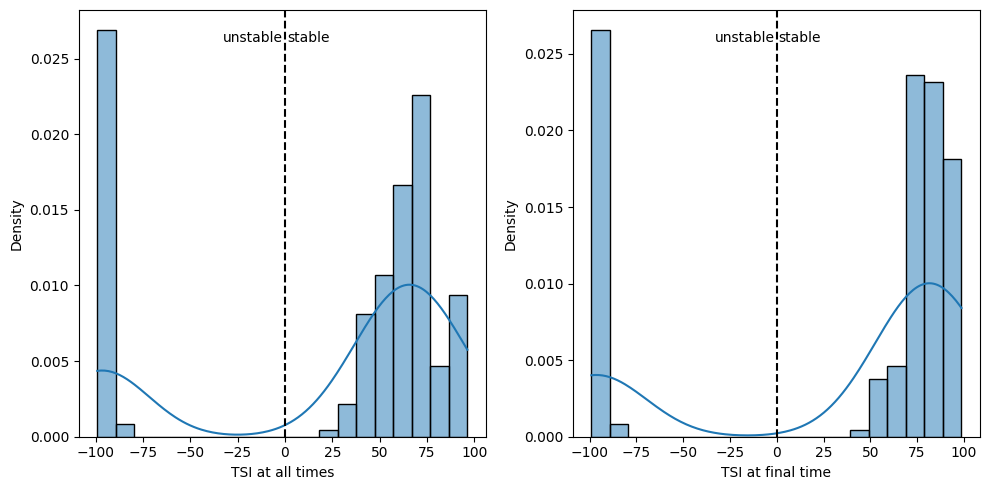

In [6]:
post_data = ComputeTSI('./simulation_log.json')

# Group the UIDs by the sample_idxs

In [7]:
from collections import defaultdict

# Create dict mapping sample_idx -> list of keys
fault_location_map = defaultdict(list)
for k, v in simulation_log.items():
    fault_location_map[v["fault_location"]].append(k)

# Convert back to normal dict if desired
fault_location_map = dict(fault_location_map)

print(fault_location_map)

{1: ['988e2e27-8aeb-4f61-866b-6f5777611278', '40ae371d-4f3e-4d3f-b972-80aa66f9e260', '03bec5ac-63f9-4682-8e75-d00d8eeda450', '5c0ad2d6-a484-493f-bcfe-47097fe31403', 'ffc09b12-9fbf-4fbc-abaa-b5a8217b7d8b', '79f55057-d69f-424c-94ae-f69e9856b837', 'fd92822f-8e21-48c2-a5b8-23d4a0bb5429', 'f7ef43c2-b07a-4cc0-a278-9361092f535e', '44a2efc1-c4d8-43f7-a428-2899b1e28a8e', '843b9abc-6aa0-4ce6-b461-e80e123b09cd', '574efe0f-9da9-4e88-80d4-b0a5915e2e66', '49a79271-9346-4a9c-bdf1-4c246de060ff', 'ece360e4-10ff-4b23-87d2-43b97d28c991', 'e41e111e-6668-4bde-b167-52df9379b068', 'b5368ce1-f2f1-490f-ae1c-f765633b114a', '4fbb4f27-f5b6-414f-b778-38e632237c74', '5d12ee91-6516-4462-b813-27aaeff09a4f', '8f469505-dc5b-44dd-9f4b-d9caac063c51', '8a725287-d3df-48cd-9e50-8f1198925402', 'c12021fd-65f5-40a6-ae26-82af3ee4db3c', 'cb0f613b-6295-4675-96df-b09532f85d1c', '58cad8cf-5f48-4ee3-8af0-f657220f92ba', '2c8904fa-9b93-44c1-8754-554cda2b67b9', '115643fc-4248-4891-93c9-137bb4e035b7', 'ab103270-cf23-478a-beb7-17c9168056

In [8]:
# build a mapping from uuid -> index
uuid_to_idx = {uuid: i for i, uuid in enumerate(post_data["pl_per_scenario"])}

# Create dicturnary for the fault location and missing faults
fault_location_with_indices = {}
removed_uuids = {}  # store the missing ones here

for floc, uuids in fault_location_map.items():
    valid_uuids = []
    indices = []
    missing = []

    for uid in uuids:
        if uid in uuid_to_idx:
            valid_uuids.append(uid)
            indices.append(uuid_to_idx[uid])
        else:
            missing.append(uid)

    fault_location_with_indices[floc] = {
        "uuids": valid_uuids,
        "indices": indices,
    }

    if missing:  # only add if there are missing keys
        removed_uuids[floc] = missing

print("With indices:", fault_location_with_indices)
print("Removed UUIDs:", removed_uuids)

With indices: {1: {'uuids': ['988e2e27-8aeb-4f61-866b-6f5777611278', '40ae371d-4f3e-4d3f-b972-80aa66f9e260', '03bec5ac-63f9-4682-8e75-d00d8eeda450', '5c0ad2d6-a484-493f-bcfe-47097fe31403', 'ffc09b12-9fbf-4fbc-abaa-b5a8217b7d8b', '79f55057-d69f-424c-94ae-f69e9856b837', 'fd92822f-8e21-48c2-a5b8-23d4a0bb5429', 'f7ef43c2-b07a-4cc0-a278-9361092f535e', '44a2efc1-c4d8-43f7-a428-2899b1e28a8e', '843b9abc-6aa0-4ce6-b461-e80e123b09cd', '574efe0f-9da9-4e88-80d4-b0a5915e2e66', '49a79271-9346-4a9c-bdf1-4c246de060ff', 'ece360e4-10ff-4b23-87d2-43b97d28c991', 'e41e111e-6668-4bde-b167-52df9379b068', 'b5368ce1-f2f1-490f-ae1c-f765633b114a', '4fbb4f27-f5b6-414f-b778-38e632237c74', '5d12ee91-6516-4462-b813-27aaeff09a4f', '8f469505-dc5b-44dd-9f4b-d9caac063c51', '8a725287-d3df-48cd-9e50-8f1198925402', 'c12021fd-65f5-40a6-ae26-82af3ee4db3c', 'cb0f613b-6295-4675-96df-b09532f85d1c', '58cad8cf-5f48-4ee3-8af0-f657220f92ba', '2c8904fa-9b93-44c1-8754-554cda2b67b9', '115643fc-4248-4891-93c9-137bb4e035b7', 'ab103270-c

In [9]:
filename = f"IEEE9_{len(post_data['pl_per_scenario'])}"

create_training_samples(post_data)

tsi_all_time {'0252a705-2477-4f79-be98-345be0199512': array([81.38713876, 81.38713876, 81.38713876, ..., 80.63771337,
       80.63759534, 80.63747607], shape=(1203,)), '026c51c8-461b-4d39-a776-e63f0e2db80e': array([87.07363177, 87.07363177, 87.07363177, ..., 86.73883797,
       86.73962833, 86.74045274], shape=(1203,)), '03462aa8-8c82-48a0-a7a6-0c480f70874d': array([58.29256162, 58.29256162, 58.29256162, ..., 56.41294805,
       56.40352896, 56.39292944], shape=(1203,)), '03bec5ac-63f9-4682-8e75-d00d8eeda450': array([77.28548225, 77.28548225, 77.28548225, ..., 76.43069045,
       76.43117126, 76.43165919], shape=(1203,)), '040fa69f-6483-4cac-88cc-be8576ecb1a5': array([90.96697158, 90.96697158, 90.96697158, ..., 91.08905781,
       91.08883994, 91.08865407], shape=(1203,)), '04683bac-0f03-4965-9d52-f24d620ae4ff': array([62.07753186, 62.07753186, 62.07753186, ..., 57.16157631,
       57.17566526, 57.1899418 ], shape=(1203,)), '063b62fa-44aa-40b0-b68a-daac785763bb': array([87.03326891, 87

In [10]:
data = scio.loadmat('./IEEE9_240_samples_20250905_141624.mat')
# data = scio.loadmat('./IEEE9_240_samples_20250902_144144.mat')
# data = scio.loadmat('./IEEE9_240_samples_20250902_155032.mat')


In [11]:
col_name = [s.strip() for s in data['col_name']]
print(col_name)

pg_idx = [i for i, x in enumerate(col_name) if x.startswith("pg")]
qg_idx = [i for i, x in enumerate(col_name) if x.startswith("qg")]
pl_idx = [i for i, x in enumerate(col_name) if x.startswith("pl")]
ql_idx = [i for i, x in enumerate(col_name) if x.startswith("ql")]

print("pg indices:", pg_idx)
print("qg indices:", qg_idx)
print("pl indices:", pl_idx)
print("ql indices:", ql_idx)

['pg_1', 'pg_2', 'pg_3', 'qg_1', 'qg_2', 'qg_3', 'pl_1', 'pl_2', 'pl_3', 'ql_1', 'ql_2', 'ql_3', 'tsi', 'tsi_t1', 'tsi_t2', 'tsi_t3', 'tsi_t4', 'tsi_t5', 'tsi_t6', 'tsi_t7', 'tsi_t8', 'tsi_t9', 'tsi_t10', 'tsi_t11', 'tsi_t12', 'tsi_t13', 'tsi_t14', 'tsi_t15', 'tsi_t16', 'tsi_t17', 'tsi_t18', 'tsi_t19', 'tsi_t20', 'tsi_t21', 'tsi_t22', 'tsi_t23', 'tsi_t24', 'tsi_t25', 'tsi_t26', 'tsi_t27', 'tsi_t28', 'tsi_t29', 'tsi_t30', 'tsi_t31', 'tsi_t32', 'tsi_t33', 'tsi_t34', 'tsi_t35', 'tsi_t36', 'tsi_t37', 'tsi_t38', 'tsi_t39', 'tsi_t40', 'tsi_t41', 'tsi_t42', 'tsi_t43', 'tsi_t44', 'tsi_t45', 'tsi_t46', 'tsi_t47', 'tsi_t48', 'tsi_t49', 'tsi_t50', 'tsi_t51', 'tsi_t52', 'tsi_t53', 'tsi_t54', 'tsi_t55', 'tsi_t56', 'tsi_t57', 'tsi_t58', 'tsi_t59', 'tsi_t60', 'tsi_t61', 'tsi_t62', 'tsi_t63', 'tsi_t64', 'tsi_t65', 'tsi_t66', 'tsi_t67', 'tsi_t68', 'tsi_t69', 'tsi_t70', 'tsi_t71', 'tsi_t72', 'tsi_t73', 'tsi_t74', 'tsi_t75', 'tsi_t76', 'tsi_t77', 'tsi_t78', 'tsi_t79', 'tsi_t80', 'tsi_t81', 'tsi_t82', 'ts

In [12]:
# The number of names not contain tsi plau the name tsi
numb_var = sum(1 for x in col_name if "tsi" not in x)
n_input = numb_var + 1
n_col = len(col_name)
n_sample = data['Data'].shape[0]

In [13]:
A = data['Data']
mask = (A[:, -1] > 50) & (A[:, n_input+1] < 0)
idx = np.flatnonzero(mask)
count = idx.size

print("Count:", count)
print("Row indices:", idx)

Count: 0
Row indices: []


In [14]:
flocs = list(fault_location_with_indices.keys())
print(flocs)

print(fault_location_with_indices[1]['indices'])

[1, 2, 3, 4, 5, 6, 7, 8, 9]
[149, 68, 3, 100, 239, 122, 237, 231, 71, 126, 95, 78, 221, 212, 169, 82, 101, 138, 134, 181, 192, 96, 50, 16, 163, 63, 98, 160, 209, 44]


# Check the number of stable and unstable TSIs for each fault

In [15]:
flocs = list(fault_location_with_indices.keys())
stable_unstable_floc = []
stable_unstable_unstable_idx = []

for floc in flocs:
    # A = data['Data']
    print(f"Fault Location: {floc}")
    floc_idx = fault_location_with_indices[floc]['indices']
    A = data['Data'][floc_idx]
    print("Total samples:", A.shape[0])

    # Total number of NaNs
    total_nans = np.isnan(A[:,-1]).sum()
    print("Count - NaN:", total_nans)

    mask = (A[:, -1] > 0) 
    idx = np.flatnonzero(mask)
    count = idx.size
    if count > 0:
        stable = True
    else:
        stable = False
    print("Count - Stable:", count)

    mask = (A[:, -1] <= 0) 
    idx = np.flatnonzero(mask)
    count = idx.size
    if count > 0:
        unstable = True
    else:
        unstable = False
    print("Count - Unstable:", count)

    total_nans = np.isnan(A[:,n_input+2]).sum()
    print("Count - NaN:", total_nans)

    mask = (A[:, n_input+2] > 0) 
    idx = np.flatnonzero(mask)
    count = idx.size
    print("Count - Init Stable:", count)

    mask = (A[:, n_input+2] <= 0) 
    idx = np.flatnonzero(mask)
    count = idx.size
    print("Count - Init Unstable:", count)


    mask = (A[:, -1] < -50) & (A[:, n_input+1] > 50)
    unstable_idx = np.flatnonzero(mask)
    count = unstable_idx.size
    print("Count:", count)
    print("Row indices:", unstable_idx)
    print("\n")

    if stable and unstable:
        stable_unstable_floc.append(floc)
        stable_unstable_unstable_idx.append(unstable_idx)
        

Fault Location: 1
Total samples: 30
Count - NaN: 0
Count - Stable: 11
Count - Unstable: 19
Count - NaN: 0
Count - Init Stable: 30
Count - Init Unstable: 0
Count: 19
Row indices: [ 1  3  4  5  6  7  8 10 13 14 15 17 18 19 22 23 24 26 29]


Fault Location: 2
Total samples: 30
Count - NaN: 0
Count - Stable: 25
Count - Unstable: 5
Count - NaN: 0
Count - Init Stable: 30
Count - Init Unstable: 0
Count: 5
Row indices: [ 1  8 19 22 23]


Fault Location: 3
Total samples: 30
Count - NaN: 0
Count - Stable: 26
Count - Unstable: 4
Count - NaN: 0
Count - Init Stable: 30
Count - Init Unstable: 0
Count: 4
Row indices: [ 1  8 22 23]


Fault Location: 4
Total samples: 30
Count - NaN: 0
Count - Stable: 27
Count - Unstable: 3
Count - NaN: 0
Count - Init Stable: 30
Count - Init Unstable: 0
Count: 3
Row indices: [ 8 22 23]


Fault Location: 5
Total samples: 30
Count - NaN: 0
Count - Stable: 27
Count - Unstable: 3
Count - NaN: 0
Count - Init Stable: 30
Count - Init Unstable: 0
Count: 3
Row indices: [ 1 22 23

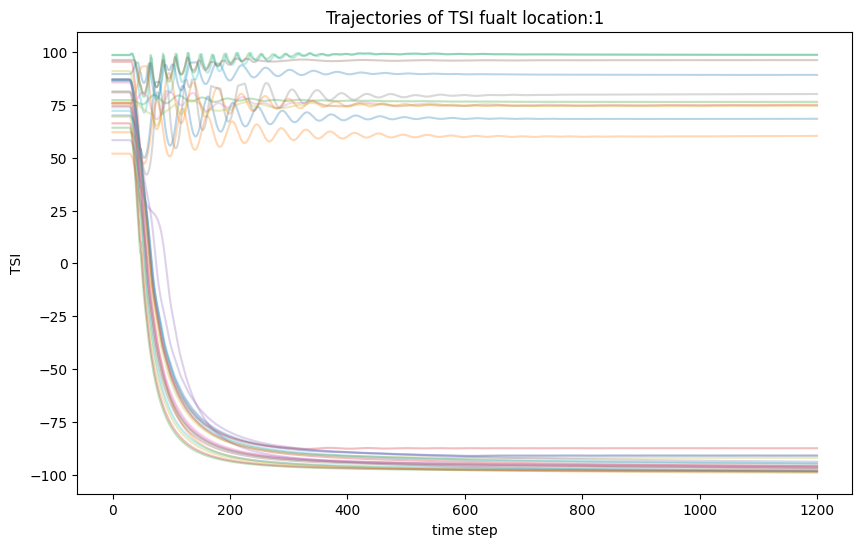

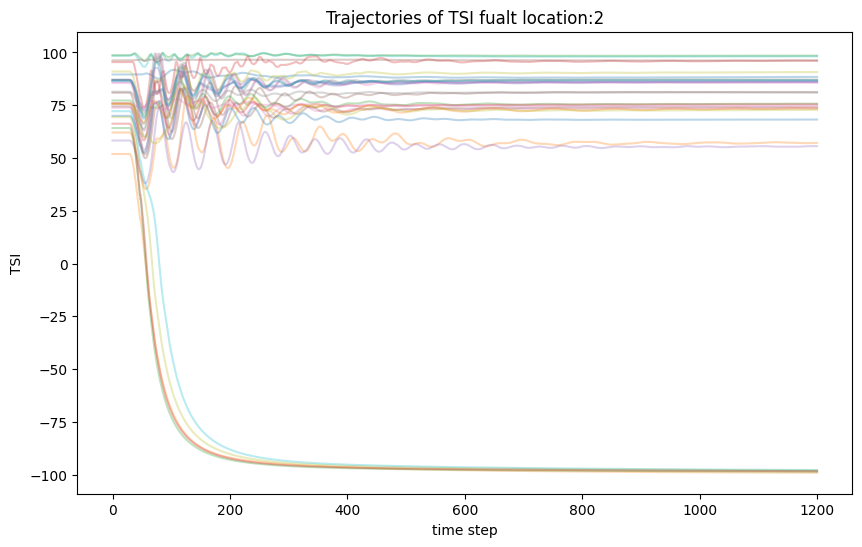

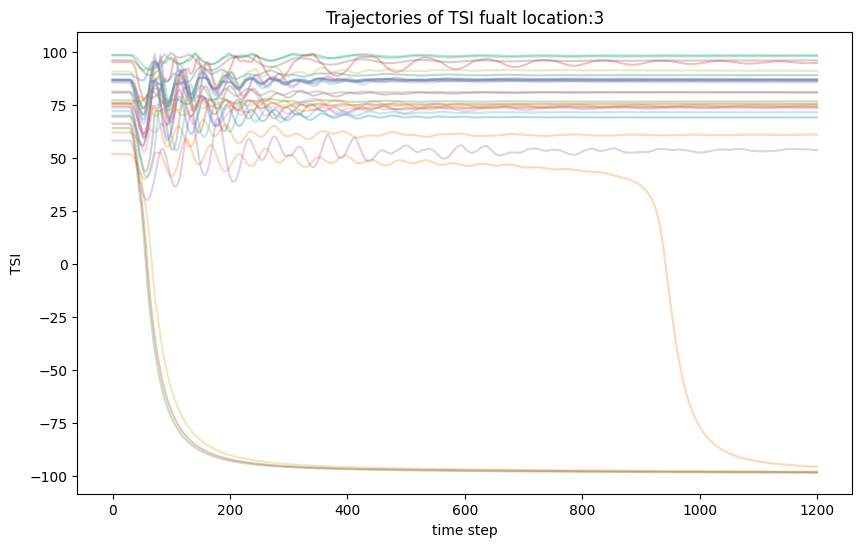

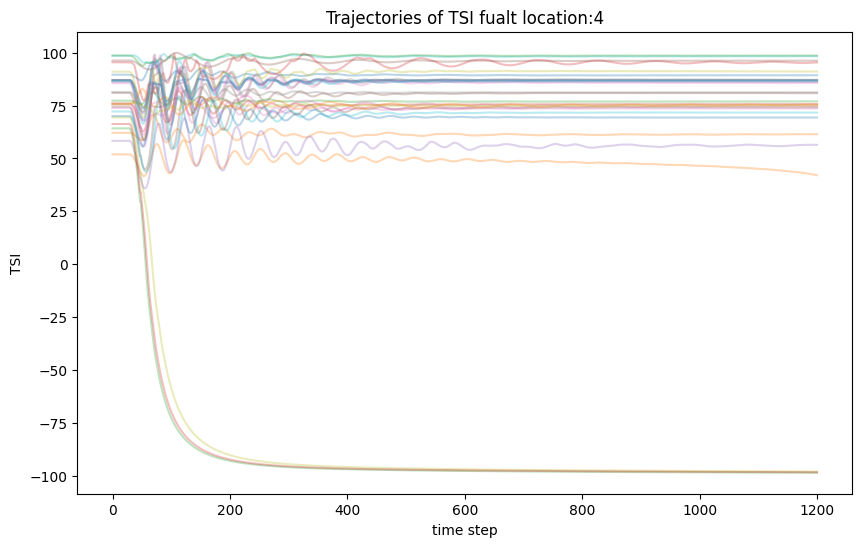

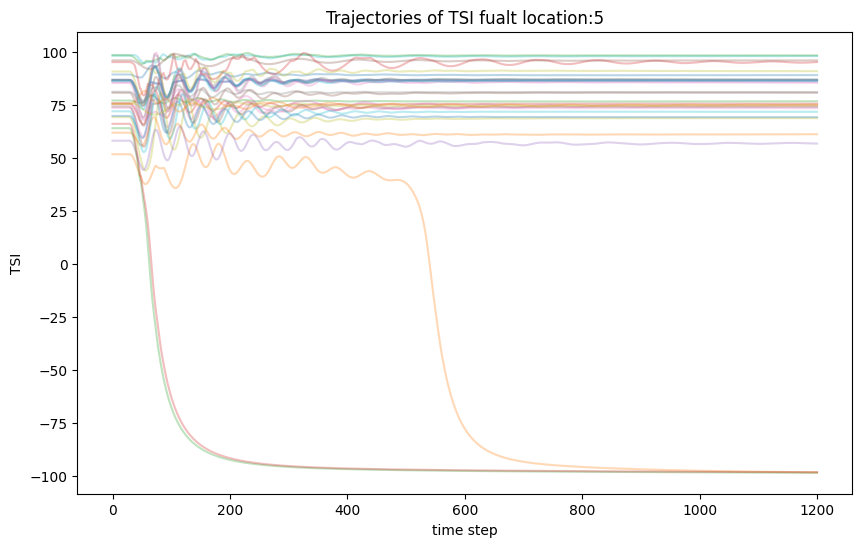

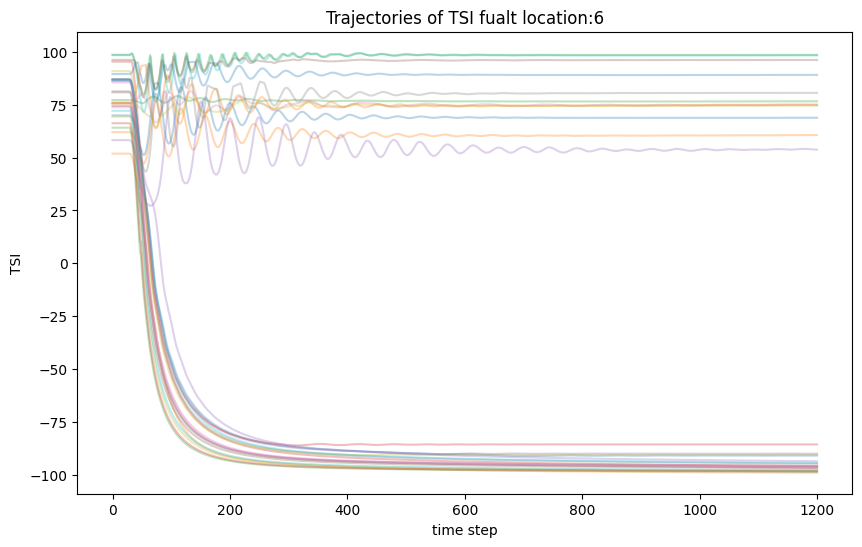

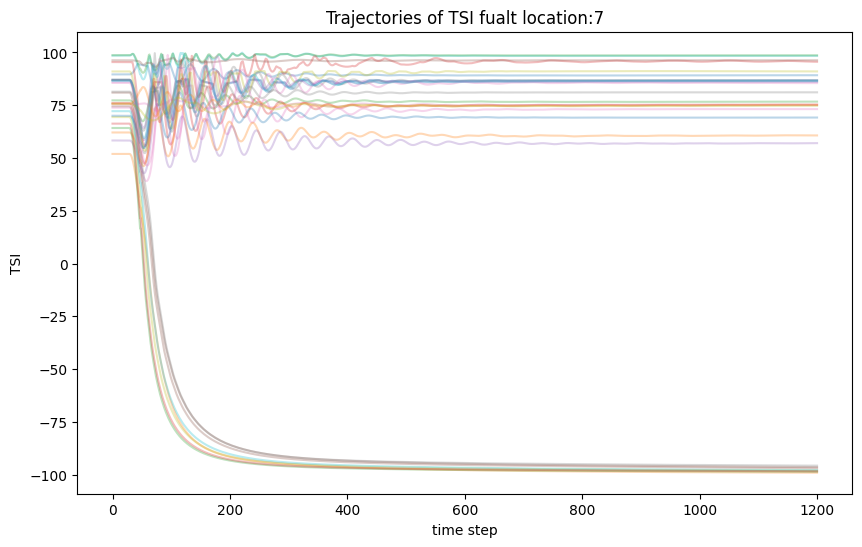

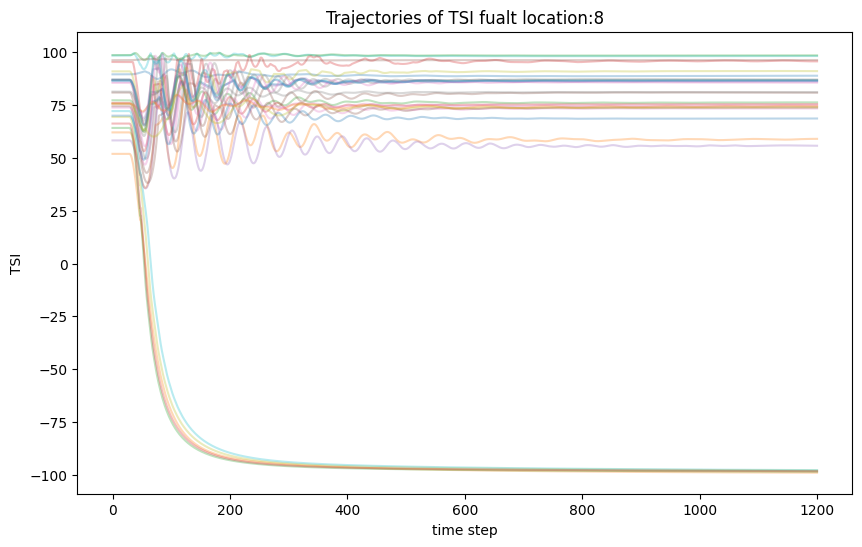

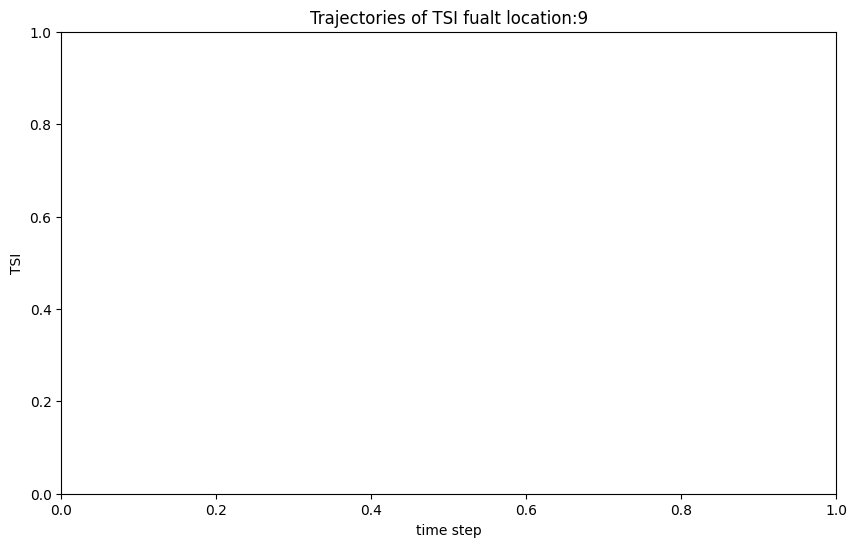

In [16]:
import matplotlib.pyplot as plt
import numpy as np


for floc in flocs:
    floc_idx = fault_location_with_indices[floc]['indices']
    TSI_Traj = np.asarray(data['Data'][floc_idx,(n_input+2):])

    # Filter rows where last column < 0
    mask = TSI_Traj[:, -1] < 0
    TSI_Traj_filtered = TSI_Traj[mask]
    TSI_Traj_filtered = TSI_Traj

    plt.figure(figsize=(10,6))

    # Plot each row as a trajectory
    for i in range(TSI_Traj_filtered.shape[0]):
        plt.plot(TSI_Traj_filtered[i, :], alpha=0.3)   # alpha makes overlapping lines transparent

    plt.xlabel("time step")
    plt.ylabel("TSI")
    plt.title(f"Trajectories of TSI fualt location:{floc}")
    plt.show()

In [17]:
alpha_samples = {}
alpha_scale = .1

for floc in flocs:
    if floc in stable_unstable_floc:
        floc_idx = fault_location_with_indices[floc]['indices']
        idx = np.where(np.array(stable_unstable_floc) == floc)[0][0]
        unstable_idx = stable_unstable_unstable_idx[idx]

        Sim_Inputs = np.asarray(data['Data'][floc_idx,:(numb_var)])

        dis = []
        dis_ind = []
        for i in range(Sim_Inputs.shape[0]):
            if i not in unstable_idx:
                dis_ind.append(i)
                dis.append((((Sim_Inputs[unstable_idx[0],:] - Sim_Inputs[i,:])**2).sum()) **.5)

        nearest_point = dis_ind[np.argmin(dis)]

        delta = Sim_Inputs[nearest_point,:] - Sim_Inputs[unstable_idx[0],:]

        samples = []
        alphas = []
        for samp in range(int(1./alpha_scale) + 1):
            alphas.append(samp)
            samples.append(Sim_Inputs[unstable_idx[0],:] + alpha_scale * samp * delta)
        
        base_pG = []
        base_qG = []
        base_pL = []
        base_qL = []
        for sample in range(len(samples)):
            base_pG.append(samples[sample][pg_idx])
            base_qG.append(samples[sample][qg_idx])
            base_pL.append(samples[sample][pl_idx])
            base_qL.append(samples[sample][ql_idx])

        alpha_samples[floc] = {
            "alphas": alphas,
            "base_pG": base_pG,
            "base_qG": base_qG,
            "base_pL": base_pL,
            "base_qL": base_qL
        }

        #Check the first and last elements are corret
        print(f"Fualt location: {floc}")
        print(samples[-1] - Sim_Inputs[nearest_point,:])

        print(samples[0] - Sim_Inputs[unstable_idx[0],:])
        print("\n")


Fualt location: 1
[0.00000000e+00 2.77555756e-17 0.00000000e+00 0.00000000e+00
 1.38777878e-17 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Fualt location: 2
[0.00000000e+00 2.77555756e-17 0.00000000e+00 0.00000000e+00
 1.38777878e-17 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Fualt location: 3
[0.00000000e+00 2.77555756e-17 0.00000000e+00 0.00000000e+00
 1.38777878e-17 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Fualt location: 4
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Fualt location: 5
[0.00000000e+00 2.77555756e-17 0.00000000e+00 0.00000000e+00
 1.38777878e-17 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000

# Run simulation for examples

In [18]:
raw = "data/ieee9_v33.raw"
dyr = "data/ieee9bus_gov.dyr"
n_bus = 9

base_psys = load_psse(raw)
add_dyr(base_psys, dyr)

balance_generation = True

/usr/WS2/hiop/dane/project/scidac_2025/irabiel/WF_ACOPF/.venv/lib/python3.10/site-packages/uqgrid/io/parse.py:68: UserWarning: Transformer Magnetizing Impedance not Implemented
  warnings.warn("Transformer Magnetizing Impedance not Implemented")


# Define the faults

In [19]:
number_of_samples = int(1./alpha_scale) + 1
fault_locations   = stable_unstable_floc
fault_impedances  = [0.0001]

scenarios = sample_scenarios(
    number_of_samples, fault_locations, fault_impedances)
metadata  = generate_metadata(scenarios)

# Create the data

In [20]:
import os

output_dir = "function_eval"

# Create a directory called "simulation_data"
os.makedirs(output_dir, exist_ok=True)

In [26]:
simulation_mult_log = {}

scenario_ids = list(metadata.keys())

for sid in scenario_ids:
    base_psys = load_psse(raw)
    add_dyr(base_psys, dyr)
    base_psys.export_state_metadata()

    # simulation_mult_log[sid] = []  # initialize list for each scenario

    sample_idx = metadata[sid]['sample_idx']
    floc = metadata[sid]['fault_location']

    alpha = alpha_samples[floc]['alphas'][sample_idx]
    base_pG = alpha_samples[floc]['base_pG'][sample_idx]
    base_qG = alpha_samples[floc]['base_qG'][sample_idx]
    base_pL = alpha_samples[floc]['base_pL'][sample_idx]
    base_qL = alpha_samples[floc]['base_qL'][sample_idx]

    fn = f"function_eval/scenario_{sid}_alpha_{alpha}.npz"

    output = run_single_scenario(
        base_psys, metadata[sid], sid,
        base_pL, base_qL,
        base_pG, base_qG,
        noise_type="normal", noise_var=0.1,
        balance_generation=True, 
        add_perturbations=False,
        fn=fn
    )

    # Merge metadata + run output + sample index
    entry = {**metadata[sid], **output, "alpha": alpha}

    # Append to the list of runs for this scenario
    simulation_mult_log[sid] = entry

with open("simulation_mult_log.json", "w") as f:
    json.dump(simulation_mult_log, f, indent=4)


# Calculate the TSI

⟳ Loading generator delta data...
⟳ loading δ for GenGENROU device 3 on bus 0
⟳ loading δ for GenGENROU device 4 on bus 1
⟳ loading δ for GenGENROU device 5 on bus 2
Found 88 common scenarios
⟳ Processing scenarios...
   Processing scenario 1/88
TSI for all scenarios: (88,)
TSI per scenario 88
TSI for all time scenarios: (88, 1203)


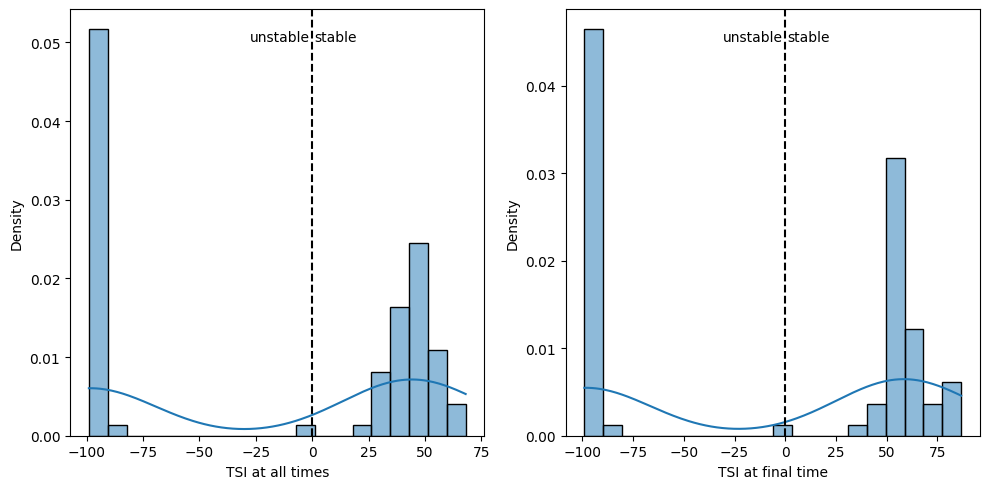

In [28]:
post_data = ComputeTSI('./simulation_mult_log.json')

# Analysis the TSI

In [30]:
# Create dict mapping sample_idx -> list of keys
floc_map_post = defaultdict(list)
for k, v in simulation_mult_log.items():
    floc_map_post[v["fault_location"]].append(k)

# Convert back to normal dict if desired
floc_map_post = dict(floc_map_post)

# print(floc_map_post)

In [32]:
# build a mapping from uuid -> index
uuid_to_idx = {uuid: i for i, uuid in enumerate(post_data["tsi_per_scenario"])}

# Create dicturnary for the fault location and missing faults
floc_with_indices = {}
removed_uuids = {}  # store the missing ones here

for floc, uuids in floc_map_post.items():
    valid_uuids = []
    indices = []
    alphas = []
    missing = []

    for uid in uuids:
        if uid in uuid_to_idx:
            valid_uuids.append(uid)
            alphas.append(simulation_mult_log[uid]["alpha"])
            indices.append(uuid_to_idx[uid])
        else:
            missing.append(uid)

    floc_with_indices[floc] = {
        "uuids": valid_uuids,
        "indices": indices,
        "alphas": alphas, 
    }

    if missing:  # only add if there are missing keys
        removed_uuids[floc] = missing

print("With indices:", floc_with_indices)
print("Removed UUIDs:", removed_uuids)

With indices: {1: {'uuids': ['cc87ce15-d602-429a-a0af-3334f9db3a86', 'a86965d9-898b-4890-9481-87d576aeec0b', 'df8e82e6-f781-4f73-92e0-ac404a3f24b4', '7333103d-04f4-491e-a311-c79452c750cd', 'c1c1982d-091c-40ef-bedf-e9b60e65f46c', 'c8c91029-a12d-4ed3-a416-1d20925e9052', '58380700-4365-4f64-a50e-21b304ea732c', '68a1ba3b-0d10-425b-b959-dce79d63ddf7', '0eef7ed3-e9f9-4de4-95cc-117f7f3adeb0', '899cff1d-7d9d-4170-93fe-278ba1ad2592', 'f67ecb58-95eb-4dda-8136-1ecd94f88e14'], 'indices': [66, 46, 74, 28, 61, 65, 21, 25, 2, 40, 82], 'alphas': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}, 2: {'uuids': ['78612d23-1c66-4d18-b830-3e11466939ea', 'a3f5e9e0-7eed-4ecd-a7fc-712d293b4f21', 'f551a37f-b158-46fc-95e6-c7a148de7f39', 'f81cad95-45ff-4f67-b059-35af8d054aec', 'f217808d-30fe-4585-b61d-a9c4ebab781d', '50f49741-1e04-43c5-9a3e-2ff156d021b1', '9dedfaa7-bd3d-4d4f-a397-faa23afbdca3', 'dfaa0ad2-439a-444b-9dbc-2b8063c80851', 'bada0502-571c-4a0c-b3a5-d5eff4faf027', '869480d8-6d78-40e6-9572-3cfd068eb56d', 'a8dfcc5a-dc3

In [33]:
tsi_results = {}

for floc, entries in floc_with_indices.items():
    tsi_end = []
    tsi_min = []
    for id in entries['uuids']:
        tsi_ts = post_data["tsi_ts_per_scenario"][id]
        tsi_end.append(tsi_ts[-1])
        tsi_min.append(np.min(np.array(tsi_ts)))

    tsi_results[floc] = {
        "tsi_min": tsi_min,
        "tsi_end": tsi_end,
        "alphas": entries["alphas"]
    }
    

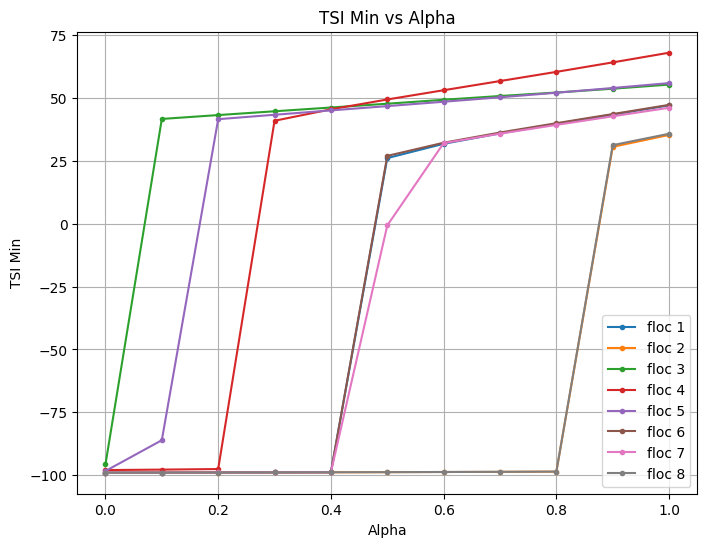

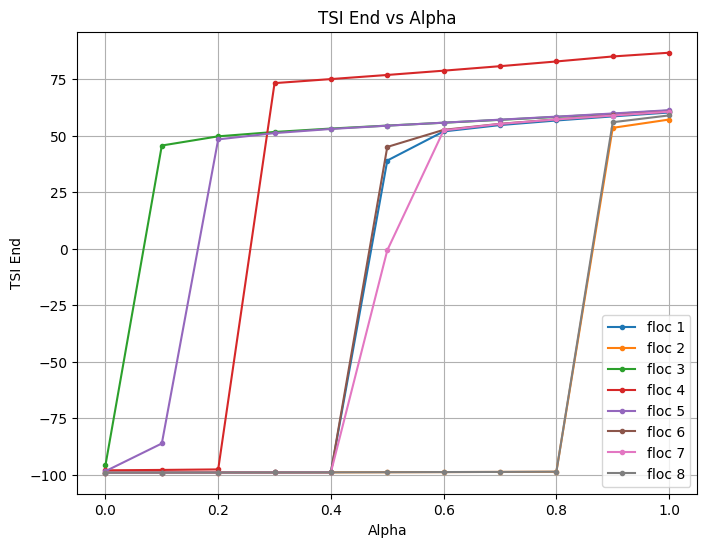

In [34]:
# --- Plot TSI_MIN ---
plt.figure(figsize=(8, 6))
for floc, values in tsi_results.items():
    plt.plot(alpha_scale * np.array(values["alphas"]), values["tsi_min"], marker=".", label=f"floc {floc}")
plt.xlabel("Alpha")
plt.ylabel("TSI Min")
plt.title("TSI Min vs Alpha")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot TSI_END ---
plt.figure(figsize=(8, 6))
for floc, values in tsi_results.items():
    plt.plot(alpha_scale * np.array(values["alphas"]), values["tsi_end"], marker=".", label=f"floc {floc}")
plt.xlabel("Alpha")
plt.ylabel("TSI End")
plt.title("TSI End vs Alpha")
plt.legend()
plt.grid(True)
plt.show()

In [95]:
data_mat = scio.loadmat("IEEE9_240_samples_20250905_090023.mat")

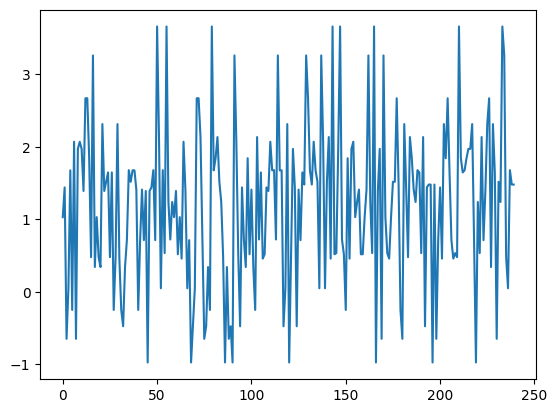

In [98]:
plt.plot(data_mat["Data"][:])

In [99]:
data_mat["Data"][:9, :9]

array([[ 0.03633305,  1.03029816,  0.68634777, -0.66228009,  2.09894759,
        -2.7378652 ,  0.29233434,  0.78271508,  0.67792956],
       [ 0.48756666,  1.44047404,  1.2887638 ,  0.14430069,  1.40044917,
        -2.78820274, -0.1548346 ,  1.3410017 ,  2.0306374 ],
       [ 2.14940879, -0.64823699,  2.34943024, -0.37010121, -0.3369668 ,
         0.2693548 ,  0.13962386,  1.50171734,  2.20926084],
       [ 0.75498645,  0.04912616,  1.36628091,  0.27712481,  0.04643895,
        -1.98032097,  0.89116421,  1.45683075, -0.17760144],
       [ 0.94712109,  1.67618278,  1.40117723, -1.70547458, -0.91925679,
         1.81240071,  1.21436043,  1.30134389,  1.50877679],
       [ 1.65065498, -0.24985873,  2.69205033, -2.55598872, -0.12463648,
         1.53594827,  2.73374737,  0.03116569,  1.32793352],
       [ 1.01097861,  2.07069149,  0.99559599, -0.20905056, -0.67945827,
         0.24091087,  2.23796288,  0.36403221,  1.475271  ],
       [ 2.14940879, -0.64823699,  2.34943024, -0.37010121, -0